In [2]:
import os
import json
import subprocess
import cv2
import matplotlib.pyplot as plt
import numpy as np


In [3]:
def split_video_sliding_window(
    video_path, 
    output_dir="forrest_cut_frame", 
    window_sec=10, 
    step_sec=2,
    exist_skip=True
):
    os.makedirs(output_dir, exist_ok=True)

    # 获取视频时长
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    duration = total_frames / fps
    cap.release()
    name=video_path.split("/")[-1].split(".")[0]
    print(f"视频总时长: {duration:.2f}s, 帧率: {fps:.2f}fps")

    # 计算滑窗数量
    num_windows = int((duration - window_sec) // step_sec) + 1

    for i in range(num_windows):
        start = i * step_sec
        end = start + window_sec

        output_path = os.path.join(output_dir, f"{name}_{int(start)}s_to_{int(end)}s.mp4")
        if exist_skip and os.path.exists(output_path):
            print(f"文件已存在，跳过: {output_path}")
            continue
        
        cmd = [
            "ffmpeg",
            "-y",  # 自动覆盖
            "-i", video_path,
            "-ss", str(start),
            "-t", str(window_sec),
            "-c", "copy",  # 不重新编码
            output_path
        ]

        print(f"保存 {start:.1f}s - {end:.1f}s → {output_path}")
        subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

def create_jsonl_from_folder(folder_path, output_path, question="请描述这个视频的主要内容"):
    with open(output_path, "w", encoding="utf-8") as f:
        for filename in sorted(os.listdir(folder_path)):
            if os.path.isfile(os.path.join(folder_path, filename)):
                item = {
                    "video": os.path.join(folder_path, filename),
                    "query": question
                }
                line = json.dumps(item, ensure_ascii=False, separators=(',', ':'))
                f.write(line + "\n")  

    print(f"JSONL：{output_path}")

create_jsonl_from_folder("forrest_cut_frame_2", "forrest.json", "Task: Please infer the emotional responses of viewers while watching the given video. Evaluate six emotional categories: happiness, surprise, sadness, anger, disgust, and fear. Each emotion should be rated on a continuous scale from 0 to 7 (with up to one decimal place), where 0 indicates no presence of the emotion, and 7 indicates very strong intensity. Please provide your response strictly in the following format (do not include any additional explanation or comments): Happiness: [score]; Surprise: [score]; Sadness: [score]; Anger: [score]; Disgust: [score]; Fear: [score]")


JSONL：forrest.json


In [ ]:
dataset={}
with open('forrest_output/forrest.json', 'r') as f:
    for i in f:
        dataset[json.loads(i)['video']]=json.loads(i)


In [ ]:
values=[]
emotions = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
basic_path='forrest_cut_frame_2'

i_time=0
while os.path.exists(os.path.join(basic_path,f"{i_time}s_to_{i_time+2}s.mp4")):
    values.append([])
    response=dataset[os.path.join(basic_path,f"{i_time}s_to_{i_time+2}s.mp4")]['response']
    for emo in emotions:
        match = re.search(rf'{emo}:\s*(\d+)', response)
        if match:
            values[-1].append(int(match.group(1)))
        else:
            values[-1].append(0)  # 如果找不到，填None或其他默认值
            #print(os.path.join(basic_path,f"{i_time}s_to_{i_time+10}s.mp4"),f"⚠️ {emo} not found in response")
    i_time+=2

In [ ]:

np.save('vilamp_score.npy',values)

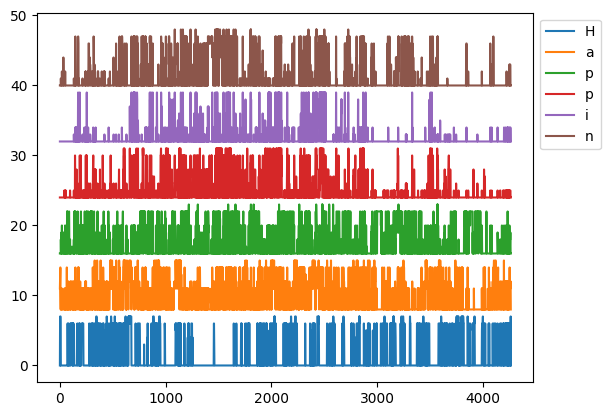

In [ ]:
values=np.load('vilamp_score.npy')
values=np.array(values)
for i in range(values.shape[1]):
    plt.plot(values[:,i]+i*8, label=emotions[i])
plt.legend(
    loc="upper right",
    bbox_to_anchor=(1.15, 1.0) 
)
plt.show()